

<center><h1><font color='darkblue'>Elektrotehnički fakultet Beograd, Računarsko modelovanje fizičkih pojava </font></h1></center>


# Prvi domaći zadatak
# školska 2024/2025. godina

***
<font color='green'>
    <p style='text-align: center;'>Luka Puco 24/0091</p>
</font>    

***
<font color='red'>Pre pradaje domaćeg zadatka, obavezno preimenovati svesku u rmfp_domaci_1_ime_prezime</font>

#### __Zadatak 1__: Bungee jumping

Nakon uspešno položenog ispita iz Računarskog modelovanja fizičkih pojava, student odlazi na Adu da polaganje ispita proslavi jednim “bungee jumping” skokom. Sa sobom je poneo nekoliko kanapa (sajli) različitih mehaničkih karakteristika (različitog koeficijenta krutosti $k$), ali su svi kanapi iste dužine $l = 15 \text{ m}$. Platforma na Adi je visoka $d = 55 \text{ m}$ i  cilj je da prilikom skoka, u trenutku kada se sajla bude maksimalno istegla, glavom ne dodirne površinu vode. Srećom, znanje fizike i stečeno znanje programskog jezika Python mogu mu pomoći da nepogrešivo odredite potreban kanap (sajlu)! 
Naime, prilikom skoka kanap će biti vezan oko članka nogu. Skok se obavlja tako što se sa ivice platforme prepusti slobodnom padu (glavom na dole) bez početne brzine. Kretanje je običan slobodan pad uz prisustvo otporne sile vazduha sve do trenutka dok se sajla ne zategne, kada na studenta počne da deluje i elastična sila sajle koja teži da ga vrati nazad. Skica sistema je data u nastavku:


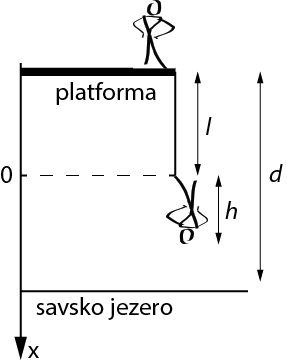




Koordinatni sistem se postavlja tako da je koordinatni početak na mestu gde se je kanap potpuno ispravljen, tj. tamo gde je njegova dužina jednaka 15 m, a $x$ osa se okreće nadole. Na taj način pozitivne vrednosti $x$ dobijaju smisao istegnuća kanapa, dok je za negativne vrednosti koordinate $x$ kanap neistegnut. Drugim rečima, ukoliko je u toku kretanja koordinata $x$ manja ili jednaka $0$, to znači da na studenta ne deluje elastična sila, odnosno jednačina kretanja ima formu slobodnog pada sa otpornom silom:
\begin{equation}
    m\frac{d^2x}{dt^2} = mg- \beta\frac{dx}{dt}
\end{equation}
gde je  $\beta$ koeficijent otporne sile vazduha u jedinici kg/s. 

Kada je koordinata $x$ veća od 0, tada se jednačini pridodaje i elastična, restituciona sila u formi: 
\begin{equation}
    m\frac{d^2x}{dt^2} = mg- \beta\frac{dx}{dt}-kx
\end{equation}
gde je $k$ koeficijent krutosti sajle u jedinici N/m. 


a) Napisati Python definiciju koja predstavlja opisani sistem, a koja za pozivne parametre uzima  masu studenta $m$, gravitaciono ubrzanje $g$ (koje iznosi 9.81 m/s^2), koeficijent otpora $\beta$ i koeficijent krutosti sajle $k$. 


In [2]:
def bandzi(y,t,m,beta,k):
    x,v=y
    if x<0:
        a=9.81-(beta/m)*v
    else:
        a=9.81-(beta/m)*v-(k/m)*x
    return [v,a]

b) Koeficijent otpora sredine zavisi od puno parametara (od toga kakvi su vremenski uslovi, do toga kakvu odeću nosite), ali prelistavanjem literature dolazite do saznanja da je prosečna vrednost $\beta=0.65 \text{ kg/s}$ . Na raspolaganju su tri kanapa, različitih koeficijenta krutosti $k_{1}=16.4 \text{ N/m}$ , $k_{2}=27.3 \text{ N/m}$ i $k_{3}=55 \text{ N/m}$. Masa studenta je  $m = 70 \text{ kg}$, a visina $h = 1.8 \text{ m}$.

Napisati glavni program koji na osnovu datih vrednosti rešava jednačinu kretanja i crta grafik koordinate $x$ vrha glave u funkciji vremena $t$. Smatrati da je položaj tela uvek vertikalan i da su ruke skupljene uz telo. Za domen rešavanja uzeti period od $0$ do $50$ sekundi u $5000$ tačaka, ili po potrebi skraćivati/produžiti vremenski opseg.  Vremenske dijagrame za različite vrednosti koeficijenta $k$ nacrtati na jednom subplot-u dimenzija 1x3, a fazne dijagrame kretanja na drugom subplot-u dimenzija 1x3. Obeležiti ose grafika. Dodati naslov i legendu.

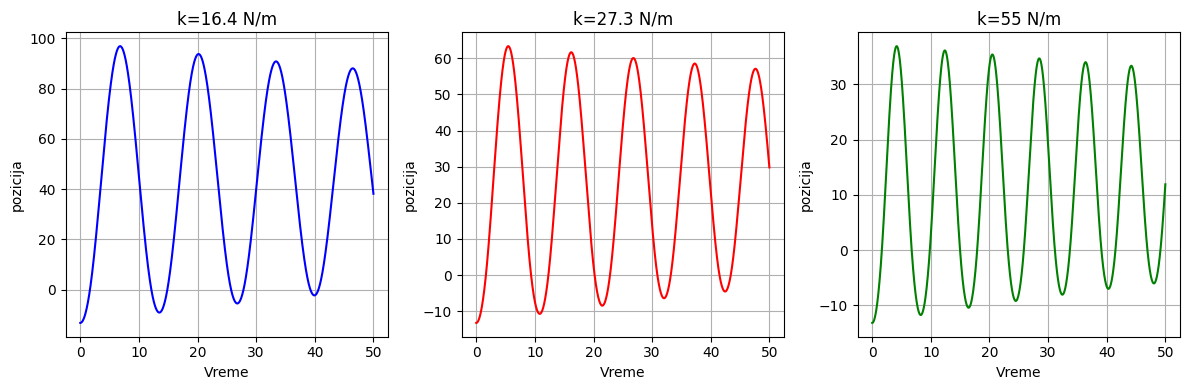

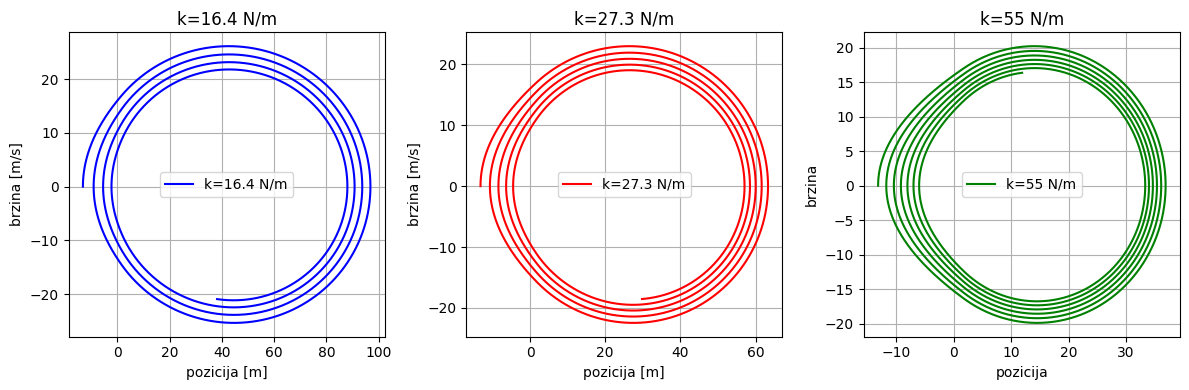

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
beta=0.65
m=70
h=1.8
l=15
y0=[-l,0.0]

k_list = [16.4, 27.3, 55]
vreme=np.linspace(0, 50, 5000)
sol_k1=integrate.odeint(bandzi,y0,vreme,args=(m,beta,k_list[0]))
sol_k2=integrate.odeint(bandzi,y0,vreme,args=(m,beta,k_list[1]))
sol_k3=integrate.odeint(bandzi,y0,vreme,args=(m,beta,k_list[2]))

sol_k1[:,0]+=h
sol_k2[:,0]+=h
sol_k3[:,0]+=h

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))
ax1.plot(vreme, sol_k1[:, 0], 'b', label='k=16.4 N/m')
ax1.set_title('k=16.4 N/m')
ax1.set_xlabel('Vreme')
ax1.set_ylabel('pozicija')
ax1.grid()
ax2.plot(vreme, sol_k2[:, 0], 'r', label='k=27.3 N/m')
ax2.set_title('k=27.3 N/m')
ax2.set_xlabel('Vreme')
ax2.set_ylabel('pozicija')
ax2.grid()
ax3.plot(vreme, sol_k3[:, 0], 'g', label='k=55 N/m')
ax3.set_title('k=55 N/m')
ax3.set_xlabel('Vreme')
ax3.set_ylabel('pozicija')
ax3.grid()
plt.tight_layout()
plt.show()


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))
ax1.plot(sol_k1[:,0], sol_k1[:,1], 'b', label='k=16.4 N/m')
ax1.set_title('k=16.4 N/m')
ax1.set_xlabel('pozicija [m]')
ax1.set_ylabel('brzina [m/s]')
ax1.grid()
ax1.legend()
ax2.plot(sol_k2[:,0], sol_k2[:,1], 'r', label='k=27.3 N/m')
ax2.set_title('k=27.3 N/m')
ax2.set_xlabel('pozicija [m]')
ax2.set_ylabel('brzina [m/s]')
ax2.grid()
ax2.legend()
ax3.plot(sol_k3[:,0], sol_k3[:,1], 'g', label='k=55 N/m')
ax3.set_title('k=55 N/m')
ax3.set_xlabel('pozicija')
ax3.set_ylabel('brzina')
ax3.grid()
ax3.legend()
plt.tight_layout()
plt.show()


c) Za koju upotrebljenu sajlu vrh glave studenta neće dodirnuti površinu vode? Obrazložiti odgovor prema dobijenim graficima. 

za krutost opruge 55N/m student nece pasti u savsko jezero, jer ce najdalje dostici visinu 37m(u odnosu na koordinantni pocetak, tj 52m u odnosu na pocetno stanje), a jezero je na 40m u odnosu na kordinantni pocetak tj. na 55m u odnosu na pocetno stanje. 

d) Za onu vrednost koeficijenta $k$ (od gornje tri ponuđene) koja obezbeđuje da vrh glave studenta neće dodirnuti površinu vode, napisati algoritam koji određuje koliko puta tokom oscilacija se prolazi kroz koordinatu $x = 0$ na kojoj prestaje delovanje elastične sile, jer kanap prestaje da bude zategnut. Na vremenskom dijagramu svaki prolazak kroz koordinatu $x = 0$ obeležiti markerom crvene boje. Obeležiti ose grafika.  

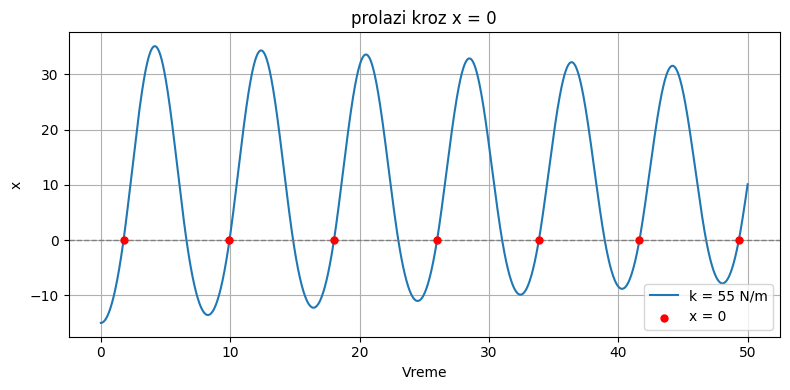

In [4]:
from scipy import integrate
import numpy as np


sol = integrate.odeint(bandzi, y0, vreme, args=(m, beta, k_list[2]))
x = sol[:, 0]
v=sol[:, 1]
sgn = np.signbit(x)
idx = np.where((x[:-1] < 0) & (x[1:] > 0))[0]

t = vreme
t_cross = t[idx] - x[idx]*(t[idx+1]-t[idx])/(x[idx+1]-x[idx])


plt.figure(figsize=(8,4))
plt.plot(t, x, label=f'k = {k_list[2]} N/m')
plt.axhline(0, color='gray', lw=1, ls='--')
plt.scatter(t_cross, np.zeros_like(t_cross), s=25, zorder=3, label='x = 0', color='red')
plt.xlabel('Vreme')
plt.ylabel('x')
plt.title('prolazi kroz x = 0')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
#na studenta ne deluje krutost opruge kada prelazi iz x<0 u x>0.

e) Za isti slučaj nacrtati fazni dijagram i prokomentarisati oblik faznog dijagrama. Na faznom dijagramu, povući jednu vertikalnu liniju koja razdvaja fazni dijagram na deo $x < 0$ i $x > 0$. Obeležiti ose grafika.   

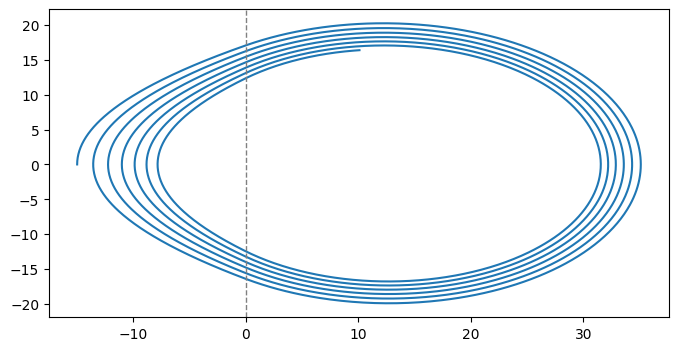

In [5]:
plt.figure(figsize=(8,4))
plt.plot(x,v, label=f'k = {k_list[2]} N/m')
plt.axvline(0, color='gray', lw=1, ls='--')
plt.show()


f) Da li je fazni dijagram idealna spirala ili postoje odstupanja od idealne spirale? Kakav je za $x < 0$, a kakav za $x > 0$? Zbog čega nastaju odstupanja?

posto postoje gubitci krive nisu idealne.
za x>0 postoje krutost opruge i koeficijent otpora pa su krive strmije
za x<0 krive su pljosnatije jer uticu samo gravitacija i otporna sila

g) Napisati algoritam koji iz vremenske zavisnosti $x(t)$ u poseban niz (maksimalne pozitivne vrednosti koordinate $x$ vrha glave studenta) izdvaja sve maksimume (sve amplitude) u vremenskom periodu od $0$ do $50$ sekundi. U drugi niz (niz nazvati vremenski_trenuci) izdvojiti vremenske trenutke u kojima se dostižu ti maksimumi i nacrtati grafik koji prikazuje zavisnost amplituda od vremenskih trenutaka. Grafik nacrtati kao niz crvenih kvadratnih markera proizvoljne veličine, povezanih plavom isprekidanom linijom. Obeležiti ose grafika. 

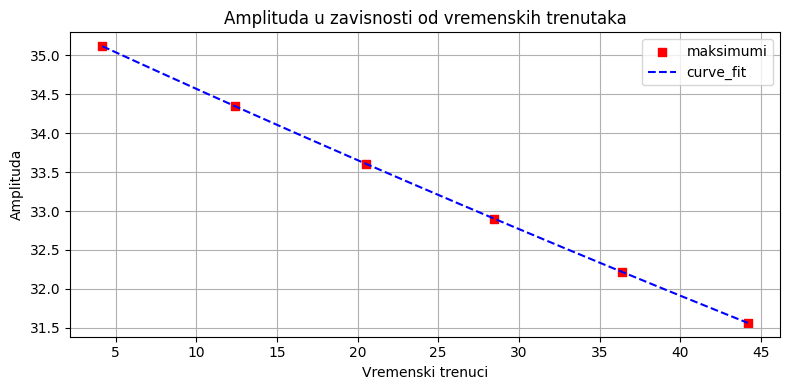

In [6]:
def pad(t, A, lamda, C):
    return A*np.exp(-lamda*t) + C

from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt


indeksi = np.where((x[1:-1] > x[:-2]) & (x[1:-1] > x[2:]) & (x[1:-1] > 0))[0] + 1
vremenski_trenuci = vreme[indeksi]
amplitude = x[indeksi]

A0 = float(amplitude[0] - amplitude[-1]) if len(amplitude) > 1 else float(amplitude[0])
p0 = [max(A0, 1e-6), 0.1, float(amplitude[-1])]
koef, cov = curve_fit(pad, vremenski_trenuci, amplitude, p0=p0)
A, lamda, C = koef

tt = np.linspace(vremenski_trenuci.min(), vremenski_trenuci.max(), 400)
plt.figure(figsize=(8,4))
plt.scatter(vremenski_trenuci, amplitude, marker='s', color='red', label='maksimumi')
plt.plot(tt, pad(tt, A, lamda, C), '--', color='blue', label='curve_fit')
plt.xlabel('Vremenski trenuci')
plt.ylabel('Amplituda')
plt.title('Amplituda u zavisnosti od vremenskih trenutaka')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### __Zadatak 2__: Sistemi sa pojavom histerezisa
Jedna od diferencijalnih jednačina koja ima veliku primenu u opisivanju određenih dinamičkih sistema u okviru ekonomije i biologije, ima formu:

\begin{equation}
    \frac{dx}{dt} = -x^3 + x + k
\end{equation}

a) Formirati Python definiciju <font color='blue'>zero_finder</font> koja pronalazi sva stacionarna rešenja jednačine u zavisnosti od parametra $k$. Pozivni parametri definicije treba da budu $k$, $x_{min}$ i $x_{max}$, odnosno vrednost parametra $k$ i opseg u kome se traže stacionarna rešenja (donja i gornja granica opsega). Definicija treba da vrati sve vrednosti promenljive $x$ koje predstavljaju stacionarna rešenja u zadatom opsegu za zadatu vrednost parametra $k$. 

Primeniti definiciju na tri slučaja: $k = -3, 0, 3$. Na istom grafiku, linijama različitih boja prikazati fazne dijagrame $dx/dt$ u funkciji od $x$ za opseg od $x_{min}$ do $x_{max}$ za tri zadate vrednosti parametra $k$. Obeležiti ose grafika, grafik nasloviti "fazni dijagram" i prikazati legendu oznaka. Isprekidanom horizontalnom linijom proizvoljne boje označiti osu $dx/dt = 0$. 

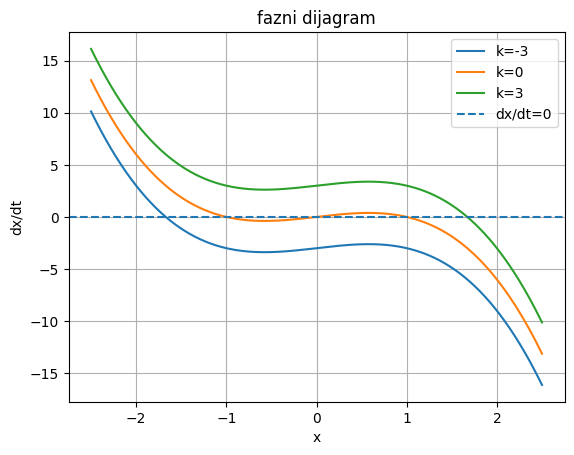

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def zero_finder(k, x_min, x_max):
    r = np.roots([1, 0, -1, -k])
    r = [z.real for z in r if abs(z.imag) < 1e-10
                    and x_min <= z.real <= x_max]
    return sorted(np.unique(np.round(r, 10)))

xmin, xmax = -2.5, 2.5
x = np.linspace(xmin, xmax, 1000)

for k in [-3, 0, 3]:
    plt.plot(x, -x**3 + x + k, label=f'k={k}')


plt.axhline(0, ls='--',label='dx/dt=0')
plt.xlabel('x'); plt.ylabel('dx/dt')
plt.title('fazni dijagram')
plt.legend(); plt.grid(True)
plt.show()




b) Komentarisati kako parametar $k$ utiče na broj stacionarnih stanja. 

prvi izvod: f'(x)=3x^2-1=0
tj. x1=1/sqrt(3)
    x2=-1/sqrt(3)
kada to ubacimo u jednacinu dobijemo da je k1=2/(3sqrt(3)) i k2 = -2/(3sqrt(3))
tj ako k pripada izmedju k2 i k1 onda cemo imati tri resenja, ako je van tog opsega onda cemo imati jedno resenje. zato plava i zelena kriva imaju jedno resenje dok narandzasta ima 3.

c) Napraviti Python definiciju <font color='blue'>histerezis</font> koja predstavlja napisanu diferencijalnu jednačinu, a zatim za $k = 0$ odrediti rešenje diferencijalne jednačine $x(t)$ u vremenskom domenu od $0$ do $100$ sekundi u $2000$ ekvidistantnih tačaka. Diferencijalnu jednačinu treba rešiti dva puta, jednom za početni uslov $x(0) = -0.00001$, drugi put za početni uslov $x(0) = 0.00001$. Rešenja prikazati na subplot $1\times 2$ grafiku. Obeležiti ose grafika i nasloviti oba grafika. U naslovima treba da stoji vrednost početnog uslova za koji je grafik dobijen.

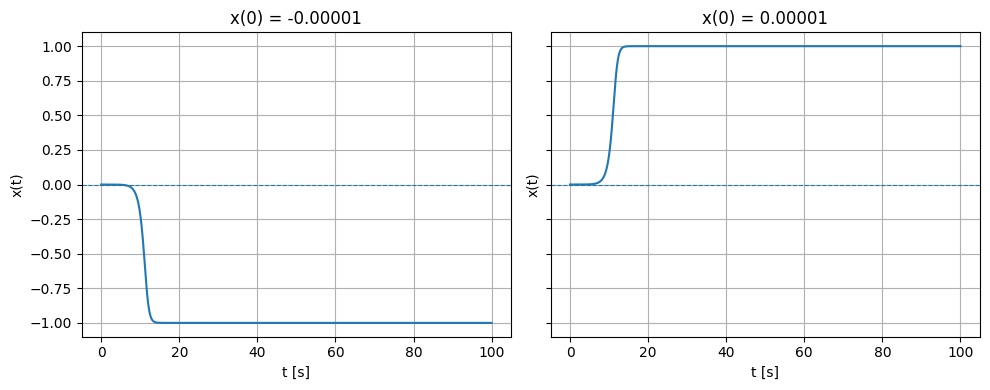

In [8]:
from scipy import integrate
def histerezis(x, t, k):
    return -x**3 + x + k

k = 0.0
t = np.linspace(0, 100, 2000)

x1 = integrate.odeint(histerezis, -1e-5, t, args=(k,))[:,0]
x2 = integrate.odeint(histerezis,  +1e-5, t, args=(k,))[:,0]

fig, ax = plt.subplots(1, 2, figsize=(10,4), sharex=True, sharey=True)
ax[0].plot(t, x1); ax[0].axhline(0, ls='--', lw=0.8)
ax[1].plot(t, x2); ax[1].axhline(0, ls='--', lw=0.8)

ax[0].set_title('x(0) = -0.00001'); ax[1].set_title('x(0) = 0.00001')
for a in ax: a.set_xlabel('t [s]'); a.set_ylabel('x(t)'); a.grid(True)

plt.tight_layout(); plt.show()


d) Da li rešenja ulaze u stacionarno stanje? Koliko iznosi stacionarno stanje u jednom, a koliko u drugom slučaju? Da li iz dobijenih rezultata sledi da je stacionarna tačka $x = 0$ privlačnog ili odbojnog karaktera?

resenja ulaze u stacionarno stanje. u x(0)=-0.00001 se dostize stacionarno stanje od -1 a u slucaju x(0)=0.00001 se dostize stanje od 1. stacionarna tacka je odbojnog karaktera jer se tacke za razlicite pocetne vrednosti udaljavaju jedna od druge.

e) Korišćenjem definicije <font color='blue'>histerezis</font> rešavati diferencijalnu jednačinu na vremenskom domenu od $0$ do $100$ sekundi u $2000$ ekvidistantnih tačaka, ali za različite vrednosti parametra $k$. Parametar $k$ varirati u rasponu od $-3$ do $3$ u 200 ekvidistantnih tačaka i za svaku vrednost rešiti diferencijalnu jednačinu za dva početna uslova, prvi put za $x(0) = -4$, drugi put za početni uslov $x(0) = 4$. U vektor <font color='blue'>x1</font> u svakoj iteraciji (za svaku vrednost parametra $k$) smeštati stacionarnu vrednost rešenja diferencijalne jednačine dobijenu za prvi početni uslov, a u vektor <font color='blue'>x2</font> smeštati stacionarnu vrednost rešenja diferencijalne jednačine dobijenu za drugi početni uslov. Za stacionarnu vrednost usvajati vrednost za $x$ u dovoljno dalekom vremenskom trenutku za koji se pretpostavlja da nastupilo stacionarno stanje. Na istom grafiku, različitim bojama nacrtati zavisnosti <font color='blue'>x1(k)</font> (punom linijom) i <font color='blue'>x2(k)</font> (isprekidanom linijom). Obeležiti ose grafika i prikazati legendu oznaka. 

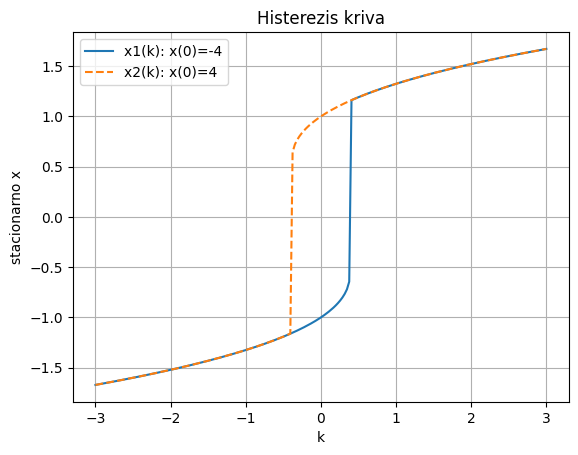

In [9]:
t = np.linspace(0, 100, 2000)
kvec = np.linspace(-3, 3, 200)

x1, x2 = [], []

for k in kvec:
    s1 = integrate.odeint(histerezis, -4.0, t, args=(k,))[:, 0]
    s2 = integrate.odeint(histerezis,  4.0, t, args=(k,))[:, 0]
    x1.append(s1[-1])
    x2.append(s2[-1])

x1 = np.array(x1); x2 = np.array(x2)

plt.plot(kvec, x1, label='x1(k): x(0)=-4')
plt.plot(kvec, x2, '--', label='x2(k): x(0)=4')
plt.xlabel('k'); plt.ylabel('stacionarno x')
plt.title('Histerezis kriva')
plt.grid(True); plt.legend()
plt.show()

f) Pomoću faznih dijagrama nacrtanih u tački a) detaljno objasniti dobijenu formu grafika. Objasniti kojom putanjom se dobijeni grafik opisuje u smeru porasta parametra $k$, a kojom putanjom u smeru smanjivanja parametra $k$.

zavisnost stacionarnog resenja od parametra k zavisi od pocetnih uslova i od smera promene parametra. Kada k raste, sistem prati plavu liniju i u jednom trenutku naglo prelazi na visu granu resenja. Kada k opada, sistem prati narandzastu liniju i naglo prelazi na nizu granu resenja. Tako se formira petlja koja pokazuje da sistem moze imati vise stabilnih stanja u zavisnosti od istorije promene parametra.

#### __Zadatak 3__: Van der Pol-ov oscilator
Van der Pol-ova jednačina predstavlja nelinearnu diferencijalnu jednačinu drugog reda sličnu jednačini prigušenih oscilacija i ima formu:

\begin{equation}
    \frac{d^2x}{dt^2} + \mu(x^2 - 1)\frac{dx}{dt} + x = 0
\end{equation}

gde je $\mu$ parametar koji modeluje prigušenje (ujedno i "jačinu nelinearnosti" jednačine) i za koji važi da je $\mu \geq 0$. Istorijski jednačina opisuje napon u jednom nelinearnom električnom kolu koje je služilo kao oscilator u prvim radio aparatima. Osim domena elektronike, jednačina ima svoje primene i u laserskoj tehnici (laser je tip van der Pol-ovog oscilatora), biologiji (opisivanje električnog potencijala neurona), seizmologiji (prostiji modeli zemljotresa) itd.  

a) Formirati Python definiciju <font color='blue'>vanderpol</font> koja predstavlja datu diferencijalnu jednačinu i za pozivni parametar ima parametar $\mu$. Rešiti jednačinu na vremenskom domenu od $0$ do $30$ u $1000$ ekvidistantnih tačaka, za početne uslove $x(0) = 0.5$ i $dx/dt = 0$ i za četiri vrednosti parametra $\mu$, $\mu = 0.1, 2, 5, 10$. Prikazati zavisnosti $x(t)$ u okviru jednog $2\times 2$ subplot-a. Obeležiti ose svake ćelije grafika i nasloviti svaku ćeliju grafika. U naslovu je potrebno da stoji odgovarajuća vrednost parametra $\mu$. Na drugom $2\times 2$ subplot-u nacrtati fazne dijagrame $dx/dt$ u funkciji od $x$. Obeležiti ose svake ćelije grafika i nasloviti svaku ćeliju grafika. U naslovu je potrebno da stoji odgovarajuća vrednost parametra $\mu$. 

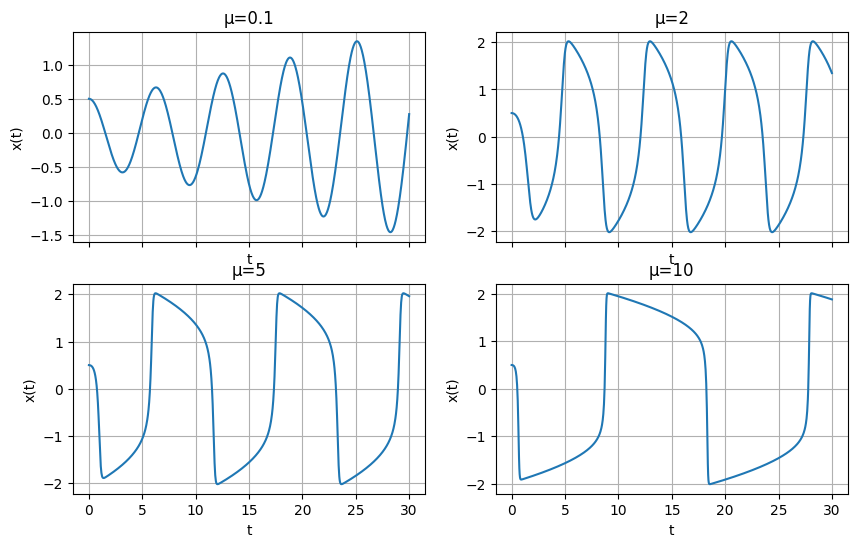

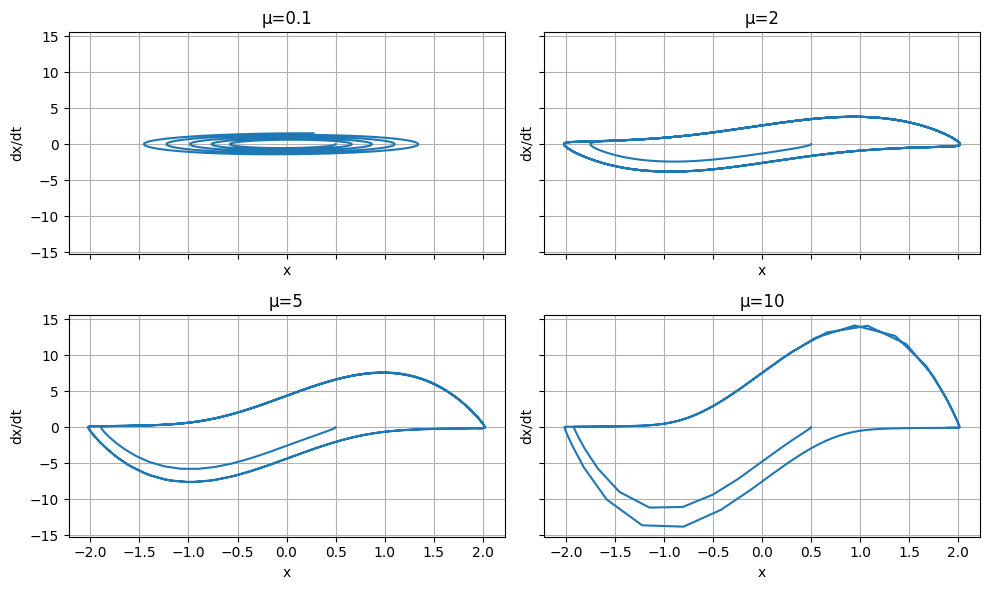

In [10]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
def vanderpol(y, t, mi):
    x, v = y
    return [v, -mi*(x**2 - 1)*v - x]

t = np.linspace(0, 30, 1000)
mi_list = [0.1, 2, 5, 10]
y0 = [0.5, 0.0]

fig1, ax1 = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
fig2, ax2 = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)

for i, mi in enumerate(mi_list):
    sol = odeint(vanderpol, y0, t, args=(mi,))
    a1, a2 = ax1.ravel()[i], ax2.ravel()[i]

    a1.plot(t, sol[:,0]); a1.set_title(f'μ={mi}')
    a1.set_xlabel('t'); a1.set_ylabel('x(t)'); a1.grid(True)

    a2.plot(sol[:,0], sol[:,1]); a2.set_title(f'μ={mi}')
    a2.set_xlabel('x'); a2.set_ylabel('dx/dt'); a2.grid(True)

plt.tight_layout(); plt.show()


b) Komentarisati kako parametar $\mu$ utiče na dobijenu dinamiku. Kakve su oscilacije u slučaju malog "prigušenja", a kakve u slučaju velikog? Komentarisati oblike faznih dijagrama u zavisnosti od parametra $\mu$. U skladu sa datim početnim uslovima, za svaki od slučaja prepoznati početnu tačku faznog dijagrama i obeležiti je na grafiku markerom crvene boje. Komentarisati u kom smeru se iscrtava fazni dijagram. 

malo mi(0.1): fazni dijagram je gotovo elipsa; skoro sinusne oscilacije
srednje mi(2 i 5): sporo klizanje duz grana i brzi prelazi, petlja se izduzuje i postaje nesimetricna;
veliko mi(10): fazni dijagram se jos vise izduzuje po y-osi; a pozicija ima nagle skokove, pa padanja.

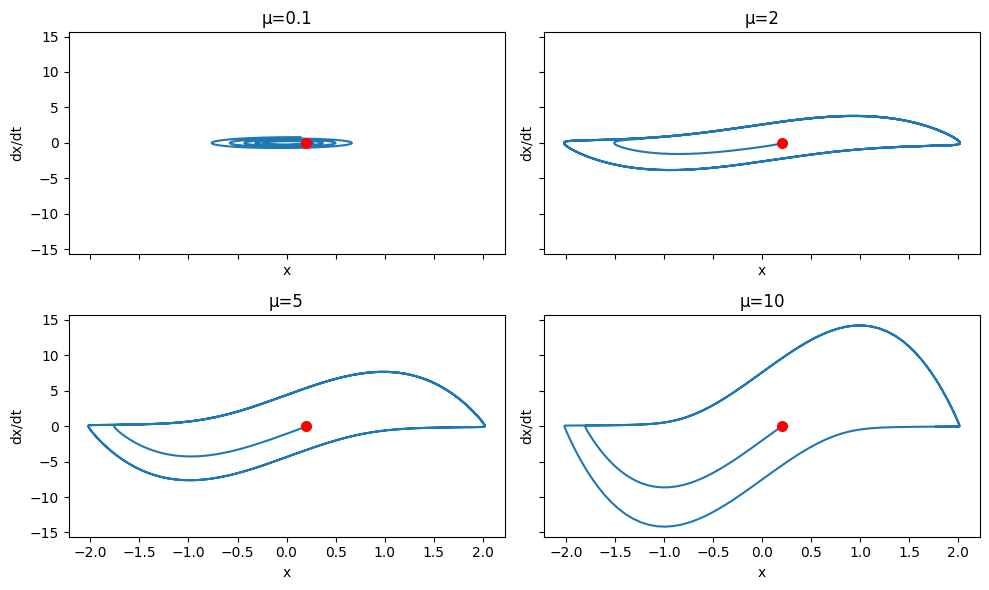

In [11]:
def add_phase_info(ax, x, xdot):
    ax.plot([x[0]], [xdot[0]], 'ro', ms=7)

mis = [0.1, 2, 5, 10]
t = np.linspace(0, 30, 5000)
z0 = [0.2, 0.0]

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i, mi in enumerate(mis):
    sol = odeint(vanderpol, z0, t, args=(mi,), atol=1e-9, rtol=1e-6, hmax=0.02)
    x = sol[:, 0]
    xdot = sol[:, 1]
    ax = axes[i]
    ax.plot(x, xdot)
    add_phase_info(ax, x, xdot)
    ax.set_title(f'μ={mi}')
    ax.set_xlabel('x')
    ax.set_ylabel('dx/dt')

plt.tight_layout()
plt.show()

c) Napisati Python definiciju <font color='blue'>maksimumi</font> koja pronalazi sve lokalne maksimume zavisnosti $x(t)$, odnosno vraća vrednosti maksimuma i vremenske trenutke u kojima se maksimumi dostižu. Primeniti funkciju na sva četiri rešenja iz prethodne tačke. Korišćenjem naredbe <font color='blue'>numpy.diff</font> kao i naredbe za srednju vrednost niza brojeva, za svaku vrednost parametra $\mu$ odrediti i ispisati period oscilacija kao srednju vrednost rastojanja između susedih maksimuma. 

In [12]:
sols = [odeint(vanderpol, y0, t, args=(mi,)) for mi in mi_list]
def maksimumi(t, x):
    m = (x[1:-1] > x[:-2]) & (x[1:-1] >= x[2:])
    idx = np.where(m)[0] + 1
    return t[idx], x[idx]
for mi, sol in zip(mi_list, sols):
    tm, xm = maksimumi(t, sol[:, 0])
    if len(tm) >= 2:
        T = np.diff(tm).mean()
        print(f"μ={mi}: period = {T:.4f} s  (broj ciklusa: {len(tm)-1})")
    else:
        print(f"μ={mi}: nema dovoljno maksimuma za procenu perioda.")

μ=0.1: period = 6.2753 s  (broj ciklusa: 3)
μ=2: period = 7.6295 s  (broj ciklusa: 3)
μ=5: period = 11.6123 s  (broj ciklusa: 2)
μ=10: period = 19.0838 s  (broj ciklusa: 1)


d) Varirati parametar $\mu$ od $0.1$ do $15$ u $20$ tačaka i u svakoj tački izračunati period oscilacija. Nacrtati grafik zavisnosti perioda oscilacija $T$ od parametra $\mu$. Obeležiti ose grafika. 

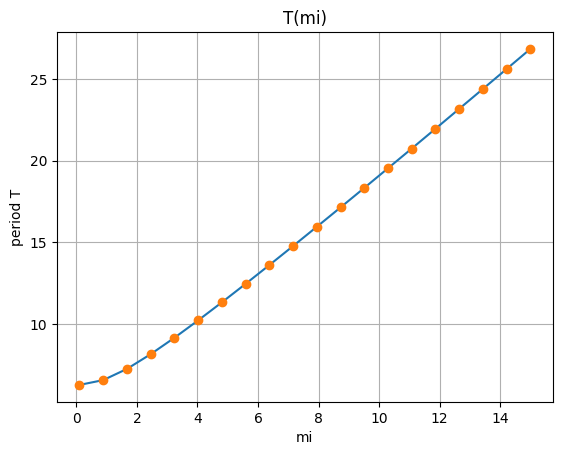

In [21]:
def maxs(t, x):
    i = np.where((x[1:-1] > x[:-2]) & (x[1:-1] >= x[2:]))[0] + 1
    return t[i], x[i]
mi = np.linspace(0.1, 15, 20)
T = []

for m in mi:
    t = np.linspace(0, 200, 10000)
    sol = odeint(vanderpol, [0.5, 0.0], t, args=(m,))
    tm, _ = maxs(t, sol[:, 0])
    if len(tm) >= 3:
        d = np.diff(tm[-8:]) if len(tm) >= 9 else np.diff(tm)
        T.append(d.mean())
    else:
        T.append(np.nan)

T = np.array(T)
plt.plot(mi,T)
plt.plot(mi, T, 'o')
plt.xlabel('mi')
plt.ylabel('period T')
plt.title('T(mi)')
plt.grid(True)

plt.show()
